Objeto 1: Área = 1946.50 px² | Perímetro = 422.27 px
Objeto 2: Área = 1955.50 px² | Perímetro = 278.95 px
Objeto 3: Área = 1116.50 px² | Perímetro = 234.47 px
Objeto 4: Área = 20416.00 px² | Perímetro = 904.49 px
Objeto 5: Área = 1704.50 px² | Perímetro = 193.36 px
Objeto 6: Área = 9.00 px² | Perímetro = 12.83 px
Objeto 7: Área = 6.00 px² | Perímetro = 10.00 px
Objeto 8: Área = 1704.50 px² | Perímetro = 190.53 px
Objeto 9: Área = 6028.50 px² | Perímetro = 418.80 px
Objeto 10: Área = 5981.50 px² | Perímetro = 432.37 px
Objeto 11: Área = 1825.50 px² | Perímetro = 193.52 px
Objeto 12: Área = 7.50 px² | Perímetro = 12.24 px
Objeto 13: Área = 11.00 px² | Perímetro = 12.83 px
Objeto 14: Área = 11.00 px² | Perímetro = 12.83 px
Objeto 15: Área = 5951.50 px² | Perímetro = 450.58 px
Objeto 16: Área = 8.50 px² | Perímetro = 11.41 px
Objeto 17: Área = 8.50 px² | Perímetro = 11.41 px
Objeto 18: Área = 5994.50 px² | Perímetro = 414.29 px
Objeto 19: Área = 5994.50 px² | Perímetro = 414.29 px
Objeto 2

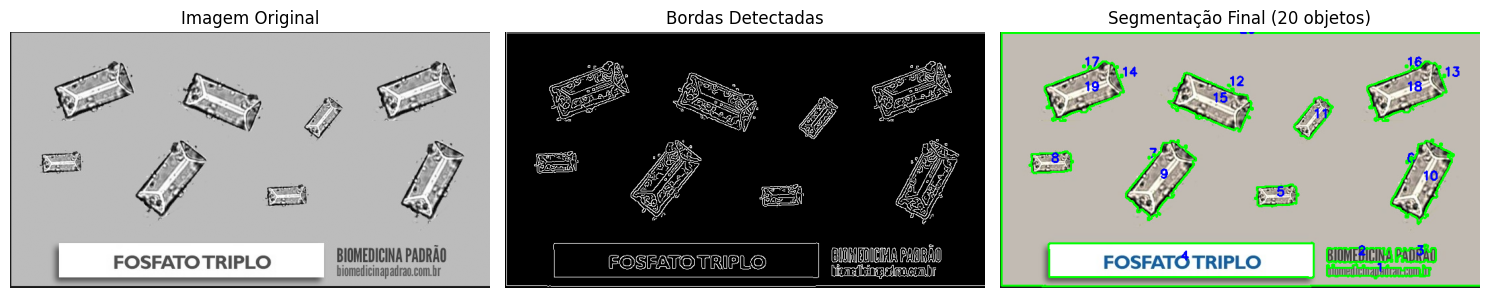

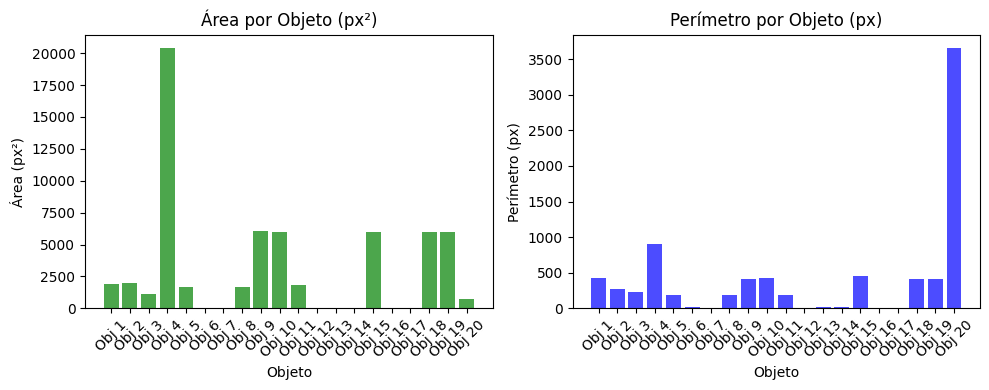

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar imagem (ou criar sintética para teste)
imagem = cv2.imread('ImagemTeste6.png')

imagem_colorida = imagem.copy()
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# 2. Suavizar para reduzir ruído
imagem_suave = cv2.GaussianBlur(imagem, (5,5), 1)

# 3. Detectar bordas com Canny
bordas = cv2.Canny(imagem_suave, 30, 100)

# 4. Fechar as bordas (dilatação + erosão)
kernel = np.ones((3,3), np.uint8)
bordas_fechadas = cv2.morphologyEx(bordas, cv2.MORPH_CLOSE, kernel)

# 5. Encontrar contornos
contornos, _ = cv2.findContours(bordas_fechadas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6. Calcular áreas e perímetros
areas = []
perimetros = []

for i, contorno in enumerate(contornos):
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)
    areas.append(area)
    perimetros.append(perimetro)
    print(f"Objeto {i+1}: Área = {area:.2f} px² | Perímetro = {perimetro:.2f} px")

# 7. Desenhar contornos na imagem original com numeração
resultado = imagem_colorida.copy()
for i, contorno in enumerate(contornos):
    # Desenhar contorno
    cv2.drawContours(resultado, [contorno], -1, (0, 255, 0), 2)
    
    # Calcular centroide para colocar número
    M = cv2.moments(contorno)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.putText(resultado, str(i+1), (cx, cy), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# 8. Criar tabela com resultados
print("\n" + "="*50)
print(f"Total de objetos encontrados: {len(contornos)}")
print(f"Área total segmentada: {sum(areas):.2f} px²")
print(f"Área média: {np.mean(areas):.2f} px²")
print(f"Área mínima: {min(areas):.2f} px²")
print(f"Área máxima: {max(areas):.2f} px²")
print(f"Perímetro total: {sum(perimetros):.2f} px")
print(f"Perímetro médio: {np.mean(perimetros):.2f} px")
print("="*50)

# 9. Mostrar resultados
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bordas, cmap='gray')
plt.title('Bordas Detectadas')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title(f'Segmentação Final ({len(contornos)} objetos)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 10. Gráfico de barras com áreas
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
objetos = [f'Obj {i+1}' for i in range(len(areas))]
plt.bar(objetos, areas, color='green', alpha=0.7)
plt.title('Área por Objeto (px²)')
plt.xlabel('Objeto')
plt.ylabel('Área (px²)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(objetos, perimetros, color='blue', alpha=0.7)
plt.title('Perímetro por Objeto (px)')
plt.xlabel('Objeto')
plt.ylabel('Perímetro (px)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()